# Acquisition Functions for Candidate Selection.

## Prepare the Notebook.

### Import the Libraries.

In [57]:
import os
import sys
import yaml

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import omegaconf
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.special import log_softmax
import seaborn as sns


### Import Additional Modules.

In [20]:
sys.path.insert(0, "../../../../shared_utils")
from experiment_utils import (
    get_g_star,
    get_forward_model,
    generate_with_condition,
    get_shuffled_populations
)

### Constants and Paths.

In [218]:
annotation_config_path = "../../../../inverse/loss_guidance/config/annotation/default.yaml"
concentration_path = "../../../../project_folder/output/miscellaneous/unique_concentrations_adata.h5ad"

base_dir = "../../../../project_folder/output/inverse/loss_guidance/raw_data"
optimization_type = "penalized_all_axes-pure_populations-reciprocal"

# target_ct = "CyclingProgenitor*"
# run_id = "2026-03-04_07-14-13_946056a2"

target_ct = "EosBasoMastPre"
run_id = "2026-03-03_06-23-17_36c12444"

target_ct_safe_string = target_ct.replace("*", "")

base_dir = os.path.join(base_dir, optimization_type)
ct_dir = os.path.join(base_dir, target_ct)
run_dir = os.path.join(ct_dir, run_id)
run_config_path = os.path.join(run_dir, "config.yaml")
candidates_path = os.path.join(run_dir, "uncertainty_annotation/candidates_with_uncertainties.csv")

## Read Data.

### Read Annotation Configurations.

In [4]:
with open(annotation_config_path, "r") as fb:
    annotation_config = yaml.safe_load(fb)
protocol_columns = annotation_config["protocol_columns"]

### Read Evaluated Candidates.

In [5]:
adata_conc = ad.read_h5ad(concentration_path)
classes = adata_conc.obs.columns.tolist()
adata_conc


AnnData object with n_obs × n_vars = 117 × 12
    obs: 'CD14-Mono', 'CD49c-Myeloid', 'CyclingProgenitor', 'DCs-CD14', 'EarlyGMP', 'Early_Pro-B', 'EosBasoMastPre', 'EosBasoMastPre_2', 'EryPro', 'GMP-Cycle', 'GMP-Neutro', 'GMP-Neutro_CD16-Mono', 'HSCs', 'MEP', 'MLP', 'MPP', 'MgkPro', 'Pro-B', 'pDCs_cDCs'

### Parse Objects from Data.

In [6]:
X_data = adata_conc.X
Y_data = adata_conc.obs.values
print(f"{X_data.shape=}, {Y_data.shape=}")

X_data.shape=(117, 12), Y_data.shape=(117, 19)


### Read Candidates Data.

In [219]:
candidates_df = pd.read_csv(candidates_path)
candidates_conf = omegaconf.OmegaConf.load(run_config_path)
candidates_df.head()

,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,MEP_prop_std,MLP_prop_std,MPP_prop_std,MgkPro_prop_std,Pro-B_prop_std,pDCs/cDCs_prop_std,exploitation_score,exploration_score,weighted_uncertainty_score,metric_response_surface
0,0,EosBasoMastPre:2026-03-03_06-23-17_36c12444:0,10.395527,0.169894,52.695490,38.074715,2.616249,11.616107,0.283424,0.000000,...,0.008871,0.002461,0.007858,0.000949,0.001500,0.007743,0.000035,0.256484,0.225566,0.128260
1,1,EosBasoMastPre:2026-03-03_06-23-17_36c12444:1,6.366437,1.211937,393.696080,78.249380,3.526419,8.960755,1.718094,0.182140,...,0.011884,0.006700,0.010348,0.002620,0.001642,0.013245,0.003059,0.542916,0.324693,0.272987
2,2,EosBasoMastPre:2026-03-03_06-23-17_36c12444:2,10.286853,2.628819,23.080765,1163.464600,1.991603,3.842678,0.011486,3.802987,...,0.010788,0.010245,0.007333,0.002521,0.001846,0.006178,0.002175,0.374553,0.102082,0.188364
3,3,EosBasoMastPre:2026-03-03_06-23-17_36c12444:3,2.590105,2.572316,223.205570,149.202930,0.417539,4.806304,2.678051,0.328223,...,0.004805,0.007323,0.008020,0.003283,0.001550,0.006589,0.242344,0.323327,0.070181,0.282836
4,4,EosBasoMastPre:2026-03-03_06-23-17_36c12444:4,0.667915,2.423275,603.815800,243.144970,3.599055,4.482005,3.885790,0.000000,...,0.008961,0.010532,0.005306,0.004103,0.002276,0.005528,0.006564,0.137480,0.130216,0.072022


### Retrieve Transformed Condition Covariates.

In [220]:
candidates_conc = candidates_df[[f"{c}:rescaled" for c in protocol_columns]]
candidates_props = candidates_df[[c for c in candidates_df.columns if c.endswith("_prop")]]
X_candidates = candidates_conc.values
Y_candidates = candidates_props.values
print(f"{X_candidates.shape=}, {Y_candidates.shape=}")

X_candidates.shape=(100, 12), Y_candidates.shape=(100, 19)


## Evaluate Surrogate Objective.

### Load Surrogate Model.

In [154]:
forward_model, (
    perturbation_response_prediction_model,
    target_prediction_model
) = get_forward_model(
    candidates_conf
)


### Query Surrogate Forward Model.

In [221]:
num_time_steps = 100
solver_kwargs = {
    "method": "euler",
    "atol": 1e-5,
    "rtol": 1e-5,
}
le_ct = None
num_samples = 1_000
fwd_query_res = generate_with_condition(
    X_candidates,
    forward_model,
    num_time_steps,
    solver_kwargs,
    le_ct,
    num_samples=num_samples,
)

### Prepare Candidate-Induced Populations.

In [222]:
g_pred = fwd_query_res["ct_probs"]
shuffled_preds_list = []
for idx in range(g_pred.shape[1]):
    pred_conc = g_pred[:, idx]
    conc_s_preds = get_shuffled_populations(pred_conc)
    shuffled_preds_list.append(conc_s_preds)
shuffled_preds = np.stack(shuffled_preds_list, axis=1)
shuffle_preds_pop_mean = shuffled_preds.mean(-2)


### Evaluate Loss Functions on Data and Candidates.

In [223]:
def loss_fn(pred, g_star):
    # g_star = np.repeat(g_star, pred.shape[0], axis=0)
    return -np.sum(g_star*log_softmax(pred, axis=-1), axis=-1)

g_pred = fwd_query_res["ct_probs"]
shuffled_preds = get_shuffled_populations(g_pred)

g_star = get_g_star(target_ct_safe_string, classes)

loss_data = loss_fn(Y_data, g_star[0])
loss_candidates = loss_fn(shuffle_preds_pop_mean, g_star[0])

mean_candidates_loss = loss_candidates.mean(-1).mean(0)
std_candidates_loss = loss_candidates.std(-1).mean(0)
print(f"{loss_data.shape=}, {mean_candidates_loss.shape=}, {std_candidates_loss.shape=}")

loss_data.shape=(117,), mean_candidates_loss.shape=(100,), std_candidates_loss.shape=(100,)


## Sequential Local Penalization.

### Define Utility Functions.


In [224]:
def compute_acq_fn(mean_loss, std_loss, kappa=1.0):
    # UCB-style acquisition: We negate the loss so we are maximizing the acquisition
    return -mean_loss + kappa * std_loss


def compute_phi(X_rest, X_max, gamma=1.0):
    """
    Computes a Gaussian local penalization function.
    Returns values in (0, 1]. 
    - Near 0: X_rest is very close to X_max (high penalty).
    - Near 1: X_rest is far from X_max (no penalty).
    """
    # Calculate squared Euclidean distance between remaining candidates and the selected point
    dists_sq = np.sum((X_rest - X_max)**2, axis=1)
    
    # Gaussian-style penalty (gamma controls the radius of the penalty)
    penalty = 1.0 - np.exp(-gamma * dists_sq)
    return penalty


def update_step_with_tracking(acq_fn, X, mean_loss, gamma=1.0):
    # Get best sample index
    max_idx = acq_fn.argmax()
    
    # Extract the actual values for the selected point
    X_max = X[max_idx][None]
    loss_val = mean_loss[max_idx]
    acq_val = acq_fn[max_idx]

    # Create boolean mask
    mask = np.ones(X.shape[0], dtype=bool)
    mask[max_idx] = False

    # Filter arrays for the next iteration
    X_rest = X[mask]
    acq_fn_res = acq_fn[mask]
    mean_loss_rest = mean_loss[mask]

    # Apply distance penalty
    phi_val = compute_phi(X_rest, X_max, gamma=gamma)
    penalized_acq = acq_fn_res * phi_val
    
    return X_max, X_rest, penalized_acq, mean_loss_rest, loss_val, acq_val


### Evaluate Acquisition.

In [225]:
# --- Execution & Tracking Loop ---
# 1. Compute the raw acquisition function
kappa = 1.0 
gamma = 1.0
raw_acq_fn = compute_acq_fn(mean_candidates_loss, std_candidates_loss, kappa=kappa)

# 2. THE FIX: Shift all values to be strictly positive
# Subtract the minimum (which is negative) to make the lowest value 0, 
# then add a constant (e.g., 1.0) so the baseline is strictly positive.
x0_acq_fn = raw_acq_fn - raw_acq_fn.min() #+ 1.0 

# ... Now proceed with the exact same loop as before ...
batch_size = 80
selected_samples = []
tracked_losses = []
tracked_acqs = []

current_X = X_candidates.copy()
current_acq = x0_acq_fn.copy()
current_loss = mean_candidates_loss.copy()

for i in range(batch_size):
    if len(current_X) == 0:
        break
        
    (X_max, 
     current_X, 
     current_acq, 
     current_loss, 
     loss_val, 
     acq_val) = update_step_with_tracking(current_acq, current_X, current_loss, gamma=gamma)
    
    selected_samples.append(X_max)
    tracked_losses.append(loss_val)
    tracked_acqs.append(acq_val)

final_batch = np.vstack(selected_samples)

### Visualize Results

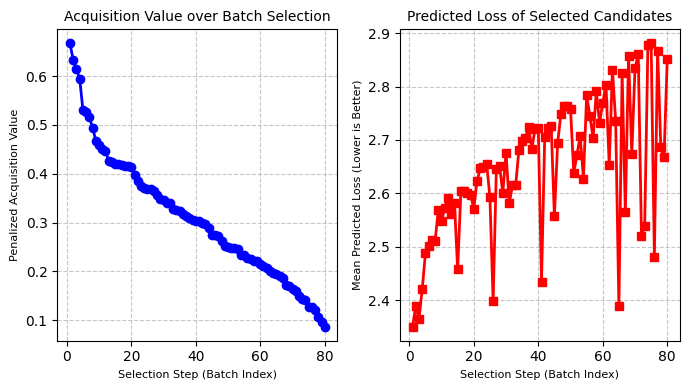

In [226]:
# --- Plotting the Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4))

epochs = np.arange(1, len(tracked_acqs) + 1)

# Plot 1: Acquisition Function Decay
ax1.plot(epochs, tracked_acqs, marker='o', color='b', linestyle='-', linewidth=2)
ax1.set_title("Acquisition Value over Batch Selection", fontsize=10)
ax1.set_xlabel("Selection Step (Batch Index)", fontsize=8)
ax1.set_ylabel("Penalized Acquisition Value", fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Surrogate Loss Trajectory
ax2.plot(epochs, tracked_losses, marker='s', color='r', linestyle='-', linewidth=2)
ax2.set_title("Predicted Loss of Selected Candidates", fontsize=10)
ax2.set_xlabel("Selection Step (Batch Index)", fontsize=8)
ax2.set_ylabel("Mean Predicted Loss (Lower is Better)", fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Quality-Weighted Determinantal Point Process

### Define Utility Functions. 

In [227]:
def compute_quality_score(mean_loss, std_loss, kappa=1.0):
    acq_val = compute_acq_fn(mean_loss, std_loss, kappa=kappa)
    # UCB-style acquisition: We negate the loss so we are maximizing the acquisition
    return np.exp(acq_val)


def select_batch_dpp_greedy(L, batch_size):
    """
    Greedy MAP inference to select a batch of candidates that approximately 
    maximizes the determinant of the sub-matrix L_Y.
    
    Parameters:
    L (np.ndarray): The N x N quality-weighted similarity matrix.
    batch_size (int): The number of candidates to select for evaluation.
    
    Returns:
    list: Indices of the selected candidates from the original pool.
    """
    pool_size = L.shape[0]
    selected_indices = []
    
    for step in range(batch_size):
        max_det = -np.inf
        best_candidate = -1
        
        for i in range(pool_size):
            # Skip if candidate is already in the batch
            if i in selected_indices:
                continue
                
            # Propose adding candidate 'i' to the current batch
            proposed_batch = selected_indices + [i]
            
            # Extract the sub-matrix for this proposed batch
            L_submatrix = L[np.ix_(proposed_batch, proposed_batch)]
            
            # Use slogdet (sign, log-determinant) for numerical stability
            # Standard np.linalg.det can underflow/overflow with large matrices
            sign, logdet = np.linalg.slogdet(L_submatrix)
            
            # Update if this candidate improves the determinant
            if sign > 0 and logdet > max_det:
                max_det = logdet
                best_candidate = i
                
        # If we found a valid candidate, add it to the batch
        if best_candidate != -1:
            selected_indices.append(best_candidate)
        else:
            # Breaks early if matrix becomes singular (extremely rare with RBF)
            print(f"Warning: Stopped early at {step} items due to numerical singularity.")
            break
            
    return selected_indices

### Evaluate Acquisition.

In [228]:
# compute distances and kernel
kappa = 1.0
gamma = 1.0
candidates_dists = cdist(X_candidates, X_candidates)
candidates_kernel = np.exp(-gamma*candidates_dists)

# compute quality score
qscore = compute_quality_score(mean_candidates_loss, std_candidates_loss, kappa=kappa)
L = candidates_kernel * np.outer(qscore, qscore)

# --- How to use it with your L matrix ---
batch_size = 75 # Change this to how many parallel evaluations you can afford
selected_indices = select_batch_dpp_greedy(L, batch_size=batch_size)

# Extract the physical coordinates to send to your true objective
X_batch_to_evaluate = X_candidates[selected_indices]

### Visualize Results.

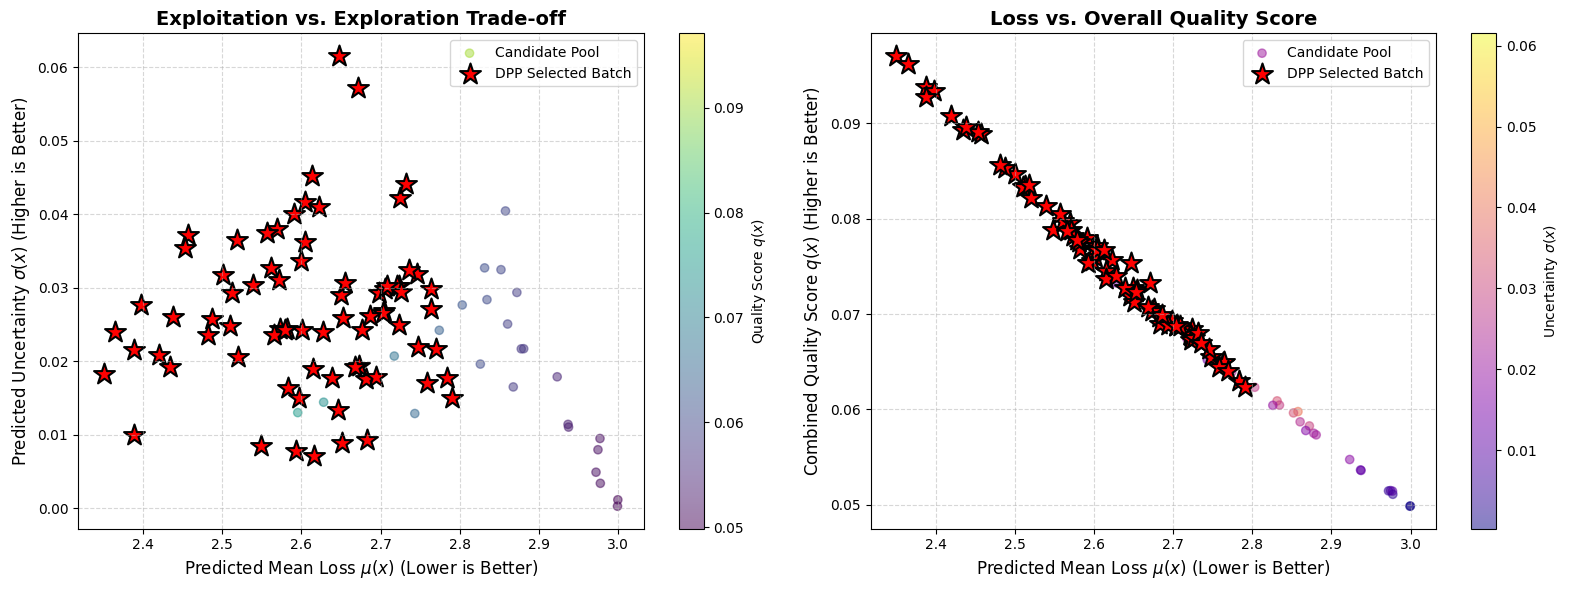

In [229]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------
# Plot 1: Mean Loss vs. Uncertainty (The Trade-off Space)
# -------------------------------------------------------------------
# Ideal points are in the Top-Left (Low Loss, High Uncertainty)
scatter1 = ax1.scatter(mean_candidates_loss, std_candidates_loss, 
                       c=qscore, cmap='viridis', alpha=0.5, label='Candidate Pool')

# Highlight selected batch
ax1.scatter(mean_candidates_loss[selected_indices], 
            std_candidates_loss[selected_indices], 
            c='red', marker='*', s=250, edgecolor='black', 
            linewidth=1.5, label='DPP Selected Batch')

ax1.set_xlabel(r'Predicted Mean Loss $\mu(x)$ (Lower is Better)', fontsize=12)
ax1.set_ylabel(r'Predicted Uncertainty $\sigma(x)$ (Higher is Better)', fontsize=12)
ax1.set_title(r'Exploitation vs. Exploration Trade-off', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()
fig.colorbar(scatter1, ax=ax1, label='Quality Score $q(x)$')

# -------------------------------------------------------------------
# Plot 2: Mean Loss vs. Quality Score
# -------------------------------------------------------------------
# Ideal points are in the Top-Left (Low Loss, High Quality)
scatter2 = ax2.scatter(mean_candidates_loss, qscore, 
                       c=std_candidates_loss, cmap='plasma', alpha=0.5, label='Candidate Pool')

# Highlight selected batch
ax2.scatter(mean_candidates_loss[selected_indices], 
            qscore[selected_indices], 
            c='red', marker='*', s=250, edgecolor='black', 
            linewidth=1.5, label='DPP Selected Batch')

ax2.set_xlabel(r'Predicted Mean Loss $\mu(x)$ (Lower is Better)', fontsize=12)
ax2.set_ylabel(r'Combined Quality Score $q(x)$ (Higher is Better)', fontsize=12)
ax2.set_title(r'Loss vs. Overall Quality Score', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()
fig.colorbar(scatter2, ax=ax2, label=r'Uncertainty $\sigma(x)$')

plt.tight_layout()
plt.show()

## Pareto Front Selection.

Found 22 candidates on the Pareto front.


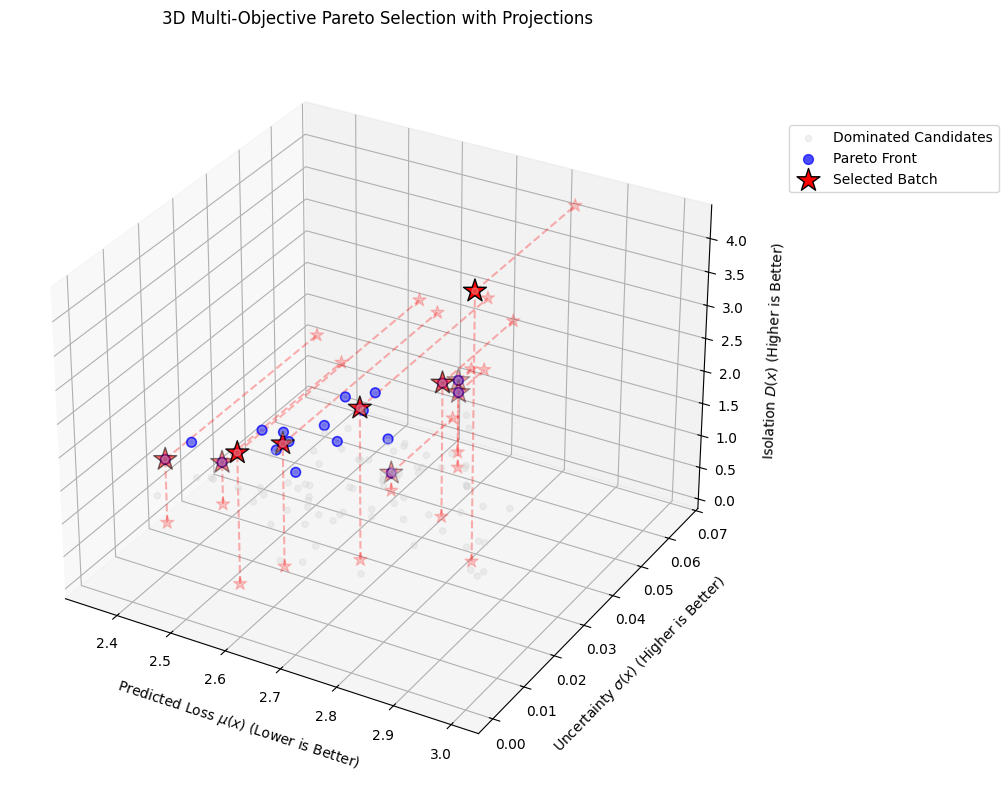

In [230]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# -------------------------------------------------------------------
# 1. Define Objectives (Assuming X_candidates, mean_loss, std_loss exist)
# -------------------------------------------------------------------
# Calculate Objective 3: Distance to nearest neighbor in the pool
dists = cdist(X_candidates, X_candidates)
np.fill_diagonal(dists, np.inf)  # Ignore distance to itself
min_dists = dists.min(axis=1)

# Stack objectives into a single (N, 3) cost matrix. 
# We negate std and dists so that smaller is always better for the algorithm.
costs = np.column_stack((
    mean_candidates_loss,   # Obj 1: Minimize loss
    -std_candidates_loss,   # Obj 2: Maximize variance
    -min_dists              # Obj 3: Maximize isolation
))

# -------------------------------------------------------------------
# 2. Fast Non-Dominated (Pareto) Sorting Algorithm
# -------------------------------------------------------------------
def get_pareto_front(costs):
    """
    Find the Pareto efficient points in a cost matrix.
    Returns the indices of the non-dominated candidates.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # A point is dominated if another point is <= on ALL objectives
            # and strictly < on at least ONE objective.
            dominators = np.all(costs <= c, axis=1) & np.any(costs < c, axis=1)
            
            if np.any(dominators):
                is_efficient[i] = False  # 'i' is dominated
            else:
                # 'i' is not dominated. Remove anything that 'i' dominates.
                dominated = np.all(costs >= c, axis=1) & np.any(costs > c, axis=1)
                is_efficient[dominated] = False
                
    return np.where(is_efficient)[0]

# Get the indices of all candidates on the Pareto front
pareto_indices = get_pareto_front(costs)
print(f"Found {len(pareto_indices)} candidates on the Pareto front.")

# -------------------------------------------------------------------
# 3. Batch Selection using Crowding Distance
# -------------------------------------------------------------------
BATCH_SIZE = 10

if len(pareto_indices) > BATCH_SIZE:
    # 1. Extract the objective values for just the Pareto front
    pareto_costs = costs[pareto_indices]
    num_points, num_objs = pareto_costs.shape
    crowding_distances = np.zeros(num_points)
    
    # 2. Calculate crowding distance for each objective
    for j in range(num_objs):
        # Sort points by this specific objective
        sorted_idx = np.argsort(pareto_costs[:, j])
        
        # The absolute boundary points get infinite distance (always keep extremes)
        crowding_distances[sorted_idx[0]] = np.inf
        crowding_distances[sorted_idx[-1]] = np.inf
        
        # Calculate the range to normalize distances
        obj_min = pareto_costs[sorted_idx[0], j]
        obj_max = pareto_costs[sorted_idx[-1], j]
        obj_range = obj_max - obj_min
        
        if obj_range == 0:
            continue
            
        # Add the normalized distance to the neighbors
        for i in range(1, num_points - 1):
            next_obj = pareto_costs[sorted_idx[i+1], j]
            prev_obj = pareto_costs[sorted_idx[i-1], j]
            crowding_distances[sorted_idx[i]] += (next_obj - prev_obj) / obj_range
            
    # 3. Sort by crowding distance (descending) and pick the top batch
    best_crowding_indices = np.argsort(crowding_distances)[::-1][:BATCH_SIZE]
    selected_indices = pareto_indices[best_crowding_indices]

else:
    print("Warning: Pareto front is smaller than batch size. Taking all Pareto points.")
    selected_indices = pareto_indices

X_selected = X_candidates[selected_indices]

# -------------------------------------------------------------------
# 4. 3D Visualization of the Pareto Front with Projections
# -------------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot all candidates (grey/transparent)
ax.scatter(mean_candidates_loss, std_candidates_loss, min_dists, 
           c='lightgrey', alpha=0.3, label='Dominated Candidates')

# Plot the Pareto front (blue)
ax.scatter(mean_candidates_loss[pareto_indices], 
           std_candidates_loss[pareto_indices], 
           min_dists[pareto_indices], 
           c='blue', alpha=0.7, s=50, label='Pareto Front')

# Extract coordinates for the selected batch
x_sel = mean_candidates_loss[selected_indices]
y_sel = std_candidates_loss[selected_indices]
z_sel = min_dists[selected_indices]

# Plot the selected batch (red stars)
ax.scatter(x_sel, y_sel, z_sel, 
           c='red', marker='*', s=300, edgecolor='black', label='Selected Batch', zorder=5)

# --- NEW: ADDING PROJECTIONS ---
# Get the axis limits to know where the "walls" and "floor" are
xlim = ax.get_xlim()
ylim = ax.get_ylim()
zlim = ax.get_zlim()

# Floor (XY plane): z = zlim[0]
ax.scatter(x_sel, y_sel, np.full_like(z_sel, zlim[0]), 
           c='red', marker='*', s=100, alpha=0.2)
for i in range(len(x_sel)):
    ax.plot([x_sel[i], x_sel[i]], [y_sel[i], y_sel[i]], [zlim[0], z_sel[i]], 
            color='red', linestyle='--', alpha=0.3)

# Back Wall (XZ plane): y = ylim[1] (assuming max y is the back wall based on standard viewing angle)
ax.scatter(x_sel, np.full_like(y_sel, ylim[1]), z_sel, 
           c='red', marker='*', s=100, alpha=0.2)
for i in range(len(x_sel)):
    ax.plot([x_sel[i], x_sel[i]], [y_sel[i], ylim[1]], [z_sel[i], z_sel[i]], 
            color='red', linestyle='--', alpha=0.3)

# # Side Wall (YZ plane): x = xlim[0] (assuming min x is the left wall)
# ax.scatter(np.full_like(x_sel, xlim[0]), y_sel, z_sel, 
#            c='red', marker='*', s=100, alpha=0.2)
# for i in range(len(x_sel)):
#     ax.plot([x_sel[i], xlim[0]], [y_sel[i], y_sel[i]], [z_sel[i], z_sel[i]], 
#             color='red', linestyle='--', alpha=0.3)
# -------------------------------

ax.set_xlabel(r'Predicted Loss $\mu(x)$ (Lower is Better)', labelpad=10)
ax.set_ylabel(r'Uncertainty $\sigma(x)$ (Higher is Better)', labelpad=10)
ax.set_zlabel(r'Isolation $D(x)$ (Higher is Better)', labelpad=10)
ax.set_title('3D Multi-Objective Pareto Selection with Projections', pad=15)

# Move legend so it doesn't block the projections
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 0.9))

plt.tight_layout()